## Diagrama de Entidad Relacion (ER) Del Dominio del PROBLEMA (entidades de existencia real)

El primer paso es siempre entender el dominio del problema y modelar sus entidades y relaciones relevantes. Estos son entidades de existencia real, no entidades de software ni de base de datos y de cuya relacion e interaccion se desprende la problemática a resolver. En este caso, la problematica yace de la complejidad de las relaciones entre las entidades reales, particularmente la prevalencia de relaciones M-M y la falta de restricciones claras en las relaciones 1-M.

De aca se desprende la necesidad de definir otras entidades, de existencia abstracta que permitan definir y gestionar más precisamente estas relaciones. Estas seran las ENTIDADES DEL DOMINIO DE LA SOLUCION.

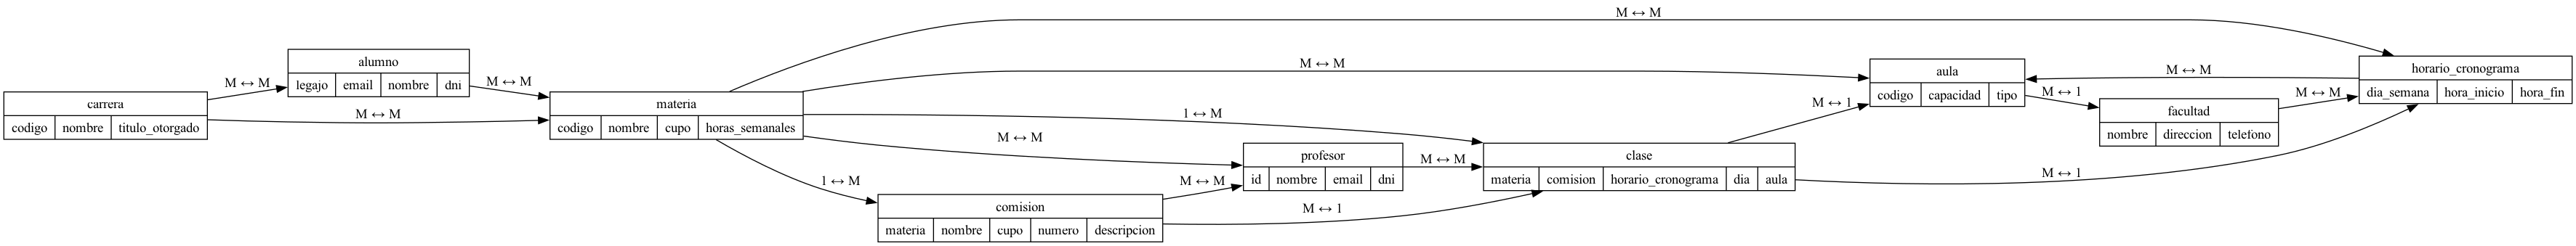

In [30]:
from graphviz import Digraph
from IPython.display import Image, display

dot_problema = Digraph(comment="Diagrama de Entidad Relacion (ER) Del Dominio del PROBLEMA", format="png")
dot_problema.attr(rankdir="LR", fontsize="10")

entidades_problema = {
    "alumno": ["legajo", "email", "nombre", "dni"],
    "materia": ["codigo", "nombre", "cupo", "horas_semanales"],
    "profesor": ["id", "nombre", "email", "dni"],
    "aula": ["codigo", "capacidad", "tipo"],
    "horario_cronograma": ["dia_semana", "hora_inicio", "hora_fin"],
    "facultad": ["nombre", "direccion", "telefono"],
    "carrera": ["codigo", "nombre", "titulo_otorgado"],
    "clase": ["materia", "comision", "horario_cronograma", "dia", "aula"], # Se define clase como un dictado de una materia en un horario y aula especificos
    "comision": ["materia", "nombre", "cupo", "numero", "descripcion"]
}

# Agregar nodos
for e, attrs in entidades_problema.items():
    label = f"{e}|{{" + "|".join(attrs) + "}}"
    dot_problema.node(e, label=label, shape="record")

# Relaciones con cardinalidades
dot_problema.edge("alumno", "materia", label="M ↔ M") # Un alumno puede estar en muchas materias y una materia puede tener muchos alumnos

dot_problema.edge("materia", "profesor", label="M ↔ M") # Un profesor puede dar muchas materias y una materia puede ser dada por muchos profesores

dot_problema.edge("materia", "clase", label="1 ↔ M") # Una materia puede dictarse en muchas clases semanales y una clase corresponde a una sola materia

dot_problema.edge("profesor", "clase", label="M ↔ M") # Un profesor puede dictar muchas clases y una clase puede ser dictada por varios profesores

dot_problema.edge("clase", "horario_cronograma", label="M ↔ 1") # Una clase se dicta en un solo horario, pero un horario puede tener muchas clases en simultaneo

dot_problema.edge("clase", "aula", label="M ↔ 1") # Una clase se dicta en un solo aula y en un aula puede dictarse muchas clases (en distintos horarios)

dot_problema.edge("materia", "aula", label="M ↔ M") # Una materia puede darse en distintas aulas y un aula puede tener muchas materias

dot_problema.edge("materia", "horario_cronograma", label="M ↔ M") # Una materia tiene varios horarios (dictados) y en un horario se pueden dictar muchas materias (en distintas aulas)

dot_problema.edge("carrera", "materia", label="M ↔ M") # Una carrera tiene muchas materias y una materia puede pertenecer a varias carreras

dot_problema.edge("carrera", "alumno", label="M ↔ M") # Un alumno puede estar en muchas carreras y una carrera tiene muchos alumnos

dot_problema.edge("horario_cronograma", "aula", label="M ↔ M") # Toda aula esta disponible en todos los horarios (a priori a asignacion) y en todos los horarios estan todas las aulas

dot_problema.edge("aula", "facultad", label="M ↔ 1") # Una facultad tiene muchas aulas, pero un aula pertenece a una sola facultad

dot_problema.edge("facultad", "horario_cronograma", label="M ↔ M") # Una facultad tiene muchos horarios (horas de apertura) y en un horario hay muchas facultades abiertas.

dot_problema.edge("materia", "comision", label="1 ↔ M") # Una materia puede tener uno o varias comisiones y una comision es de una materia

dot_problema.edge("comision", "clase", label="M ↔ 1") # Una clase corresponde a una comision y una comision puede tener muchas clases

dot_problema.edge("comision", "profesor", label="M ↔ M") # Un profesor puede dar muchas comisiones y una comision puede ser dada por muchos profesores

display(Image(dot_problema.pipe(format="png")))


NOTA: en este caso estamos modelando a las comisiones simplemente como una division de la materia a fines de distribuir los alumnos y profesores de manera de facilitar el dictado. Bien podria modelarse como un attribute de la clase.

No se contempla el caso de comisiones que sean de mas de una materia (ejemplo una comision 101 que tenga todas las materias del primer cuatri de 1ero juntos).


Resulta evidente la complejidad del problema dada la abundancia de relaciones mucho a mucho.
- Un alumno puede estar en muchas materias y una materia puede tener muchos alumnos
- Un profesor puede dar muchas materias y una materia puede ser dada por muchos profesores
- Una materia puede darse en distintas aulas y un aula puede tener muchas materias
- Una materia tiene varios horarios (dictados) y en un horario se pueden dictar muchas materias (en distintas aulas)
- Toda aula esta disponible en todos los horarios (a priori a asignacion) y en todos los horarios estan todas las aulas. Por "horario" se entiende las horas del cronograma (y no del reloj, es decir en franjas de 40min) en las que está abierta la facultad.
- Toda aula esta disponible en todos los horarios (a priori a asignacion) y en todos los horarios estan todas las aulas
- Una facultad tiene muchas aulas, pero un aula pertenece a una sola facultad

Producto de estas relaciones complejas entre las entidades del dominio del problema, de existencia concreta y real, nace la necesidad de definir entidades abstractas que ayuden a modelar y gestionar estas relaciones entre las entidades del problema. Estas serán las ENTIDADES DE LA SOLUCION.

### Entidades Centrales del Dominio del Problema

Si bien existen muchas entidades reales que intervienen en el dominio de nuestro problema, las entidades del dominio de la solución se desprenderán de la necesidad de definir y gestionar las relaciones entre las entidades que son la CAUSA de la problemática.

En este caso:
- La problematica en si es la ineficiente asignacion de aulas que a su vez yace de la falta de informacion para tomar decisiones informadas previo al inicio de clases. Esto produce inconvenientes en el dictado de clases y a menudo desencadena reasignaciones que a su vez complejizan la situación.
- La dificultad radica en hacer una adecuada gestion de aulas y asignarlas eficientemente entre las distintas materias, en función de los requerimientos y restricciones impuesto por las limitaciones de las dimensiones de las aulas (capacidad), la cantidad de alumnos por materia (inscripciones) y el comportamiento de la ASISTENCIA de estos.
- De este ultimo punto se desprende que en el dominio de la SOLUCION se definiran entidades que permitan abordar estas deficiencias. Entidades tales como ASISTENCIA y ASIGNACION.
- Dos contra ejemplos podrían ser las entidades CARRERA y FACULTAD, que si bien existen dentro del dominio del problema y tiene existencia real, son irrelevante a la solución ya que la problemática yace de la relacion entre las aulas, los alumnos y las clases. Da igual si las aulas estan todas en la misma facultad o distintas facultades, o si las materias son de una o varias carreras, no introducen ninguna complejidad adicional al problema de asignacion (según las suposiciones que hagamos y los parámetros que predefinamos para la asignación). Sí son elementos complementario, pero que no afectaran al DISEÑO de la solución.
- Resulta evidente tambien que la relacion entre MATERIA -> AULA , si bien tiene significado real, no es relevante al diseño de la solución ya que en verdad lo que interesa es la asignacion de AULAS a CLASES y no AULAS a MATERIAS (ya que no son fijas por materia, pero se puede llegar a abordar ambos caminos).

#### Objetivos
- Optimizar el uso de las aulas
- Minimizar problemas de falta de capacidad para el dictado de una clase o maximizar el uso de la capacidad instalada en todo momento.

## Definición de Alcance, Restricciones y Relaciones Relevantes
El diagrama anterior es una representación de las relaciones "coloquiales" de las entidades del problema. Sin embargo no todas son relevantes al diseño de la solución, según que restricciones o 'reglas' se definan de antemano en el contexto de la problemática de asignación de aulas.
#### Por ejemplo:
- Si bien nosotros entendemos que una materia puede ser dada en varias aulas y que una materia se dicta en varios horarios (lo cual se ve representado en el anterior diagrama), sabemos que en realidad las materias no tienen asignada un aula ni horario, si no que las clases. Así, surge la clase como el elemento central de organización y gestión de aulas.
- De manera similar, hay otros elementos como "carrera", "profesor" o "facultad" que podrán ser complementarios en la solución final y aportar otro tipo de "insights", pero que en principio escaparán a nuestro analisis y no intervendrán en el diseño de soluciones para nuestra problematica.
- En particular:
- - El profesor tendrá un rol de gestión propuesto en el diseño del sistema, así como el personal administrativo.
- - La inclusión de las carreras y facultades en el modelado del sistema de información podrá aportar información adicional para analizar la cantidad de movimientos inter-facultad que realizan alumnos de una carrera. Esto podría alimentar futuros procesos de toma de decisión o para plantear otros problemas de optimización, que en esta oportunidad, no nos competen.

### Diagrama de Entidad Relacion (ER) Del Dominio del PROBLEMA (delimitado)
De esta manera, a los fines de centrarnos en el abordaje de la problemática puntual, se puede definir un esquema delimitado con solo las relaciones y entidades relevantes al diseño de la solución. 

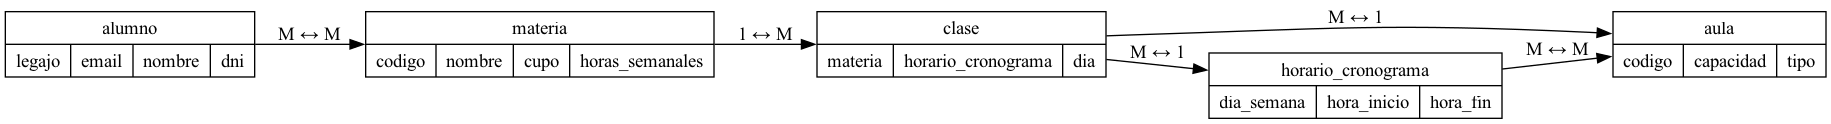

In [31]:
dot_problema_lim = Digraph(comment="Diagrama de Entidad Relacion (ER) Del Dominio del PROBLEMA (Delimitado)", format="png")
dot_problema_lim.attr(rankdir="LR", fontsize="15")

entidades_problema = {
    "alumno": ["legajo", "email", "nombre", "dni"],
    "materia": ["codigo", "nombre", "cupo", "horas_semanales"],
    "aula": ["codigo", "capacidad", "tipo"],
    "horario_cronograma": ["dia_semana", "hora_inicio", "hora_fin"],
    "clase": ["materia", "horario_cronograma", "dia"], # Se define clase como un dictado de una materia en un horario y aula especificos
}

# Agregar nodos
for e, attrs in entidades_problema.items():
    label = f"{e}|{{" + "|".join(attrs) + "}}"
    dot_problema_lim.node(e, label=label, shape="record")

# Relaciones con cardinalidades
dot_problema_lim.edge("alumno", "materia", label="M ↔ M") # Un alumno puede estar en muchas materias y una materia puede tener muchos alumnos

dot_problema_lim.edge("materia", "clase", label="1 ↔ M") # Una materia puede dictarse en muchas clases semanales y una clase corresponde a una sola materia

dot_problema_lim.edge("clase", "horario_cronograma", label="M ↔ 1") # Una clase se dicta en un solo horario, pero un horario puede tener muchas clases en simultaneo

dot_problema_lim.edge("clase", "aula", label="M ↔ 1") # Una clase se dicta en un solo aula y en un aula puede dictarse muchas clases (en distintos horarios)

dot_problema_lim.edge("horario_cronograma", "aula", label="M ↔ M") # Toda aula esta disponible en todos los horarios (a priori a asignacion) y en todos los horarios estan todas las aulas

display(Image(dot_problema_lim.pipe(format="png")))

## Por qué estas son las relaciones relevantes?

En función de los tres ejes principales del problema:
1) En función de la ASISTENCIA: un ALUMNO se inscribe a una MATERIA y luego se espera asista a sus CLASES. --> Principal Variable (Estocastica) del Problema de Optimización 
2) En función de la ASIGNACIÓN: las AULAS se asignan a CLASES y no materias.
3) En función de la DISPONIBILIDAD: las CLASES tienen asignado un HORARIO DEL CRONOGRAMA. Esto último viene determinado por las autoridades de las facultades por lo cual en este proyecto será uno de los principales supuestos y no interviene en el diseño de la solución, más allá de ser dato.

## Diagrama de Entidad Relacion (ER) Del Dominio de la SOLUCION

In [32]:
dot_solucion = Digraph(comment="Diagrama de Entidad Relacion (ER) Del Dominio de la SOLUCION", format="png")
dot_solucion.attr(rankdir="LR", fontsize="10")

entidades_solucion = {
    "inscripcion": ["alumno", "materia"],
    "asistencia": ["alumno", "clase"],
    "asignacion_aula": ["clase", "aula"],
}